In [6]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [7]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [8]:

BASE_PATHHASIL = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128/norm/dwt/"

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_tow_ids():

    inputs = layers.Input(shape=(64, 64, 3))

    # ===== Block A =====
    x = layers.SeparableConv2D(32, (3,3), padding="same")(inputs)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # ===== Block B (Residual) =====
    shortcut = layers.Conv2D(64, (1,1), padding="same")(x)

    x = layers.SeparableConv2D(64, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # ===== Block C =====
    x = layers.SeparableConv2D(128, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ===== Dense Head =====
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [10]:

train_data = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_test_dwt.npz"))
val_data   = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

X_val   = val_data["X"]
y_val   = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

(6582, 64, 64, 3) (6582,)
(6184, 64, 64, 3) (6184,)
(2821, 64, 64, 3) (2821,)


In [11]:
tf.keras.backend.clear_session()

model = build_cnn_tow_ids()
model.summary()


I0000 00:00:1778984818.418942   23540 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │        155 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 32, 32,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 32, 32,    │      8,896 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 228,348 (891.98 KB)

 Trainable params: 227,900 (890.23 KB)

 Non-trainable params: 448 (1.75 KB)

 Total params: 228,348 (891.98 KB)
 Trainable params: 227,900 (890.23 KB)
 Non-trainable params: 448 (1.75 KB)

In [12]:


history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    
)


Epoch 1/50


I0000 00:00:1778984820.870721   23778 service.cc:152] XLA service 0x715108017d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778984820.870745   23778 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-17 09:27:00.922157: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778984821.274221   23778 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-05-17 09:27:02.489098: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332_0', 44 bytes spill stores, 44 bytes spill loads

2026-05-17 09:27:02.817684: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

201/206 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8572 - loss: 0.3474

2026-05-17 09:27:11.273854: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332_0', 36 bytes spill stores, 36 bytes spill loads

2026-05-17 09:27:12.049052: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332', 488 bytes spill stores, 488 bytes spill loads

2026-05-17 09:27:13.503321: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2185', 32 bytes spill stores, 32 bytes spill loads

2026-05-17 09:27:14.239363: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2185', 28 bytes spill stores, 32 bytes spill loads

2026-05-17 09:27:14.326936: I extern

206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8585 - loss: 0.3448

2026-05-17 09:27:21.236993: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 64 bytes spill stores, 64 bytes spill loads



206/206 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9098 - loss: 0.2389 - val_accuracy: 0.6856 - val_loss: 3.8138
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9711 - loss: 0.0972 - val_accuracy: 0.6856 - val_loss: 6.1719
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9766 - loss: 0.0753 - val_accuracy: 0.6866 - val_loss: 2.3948
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9775 - loss: 0.0694 - val_accuracy: 0.8040 - val_loss: 0.7266
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9810 - loss: 0.0662 - val_accuracy: 0.4101 - val_loss: 4.4387
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9842 - loss: 0.0589 - val_accuracy: 0.8529 - val_loss: 0.4103
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9839 - loss: 0.0550 - val_accuracy: 0.5172 - val_loss: 2.4574
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9839 - loss: 0.0546 - val_accuracy: 0.4899 - va

In [13]:
# === TEST ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("\n=== TEST RESULT ===")
print("Loss :", test_loss)
print("Acc  :", test_acc)

190/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.2919

2026-05-17 09:28:42.258365: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 64 bytes spill stores, 64 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8863 - loss: 0.6629

=== TEST RESULT ===
Loss : 0.6629288196563721
Acc  : 0.8863195180892944


Threshold 0.5

In [14]:
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)


194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


Confusion Matrix + Nilai Dasar

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)


TP: 2385
FP: 200
TN: 3096
FN: 503


Hitung Semua Metric Sesuai Persamaan Paper

In [16]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
fmeasure  = 2 * precision * recall / (precision + recall)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"Precision: {precision:.6f}")
print(f"F-measure: {fmeasure:.6f}")



=== Metrics (Threshold 0.5) ===
Accuracy : 0.886320
Recall   : 0.825831
Precision: 0.922631
F-measure: 0.871551


In [17]:
# === Confusion values sudah ada ===
# tp, tn, fp, fn

accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn + 1e-12)
precision = tp / (tp + fp + 1e-12)
f1        = 2 * precision * recall / (precision + recall + 1e-12)

# tambahan
fpr = fp / (fp + tn + 1e-12)
fnr = fn / (fn + tp + 1e-12)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1        : {f1:.6f}")
print(f"FPR       : {fpr:.6f}")
print(f"FNR       : {fnr:.6f}")
print(f"FP        : {fp}")
print(f"FN        : {fn}")



=== Metrics (Threshold 0.5) ===
Accuracy  : 0.886320
Precision : 0.922631
Recall    : 0.825831
F1        : 0.871551
FPR       : 0.060680
FNR       : 0.174169
FP        : 200
FN        : 503



=== Metrics (Threshold 0.5) ===
Accuracy  : 0.981726
Precision : 0.968790
Recall    : 0.992911
F1        : 0.980702
FPR       : 0.028101
FNR       : 0.007089
FP        : 370
FN        : 82

ROC Curve + AUC (Persamaan 13)

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.6f}")


AUC: 0.949780


Plot ROC

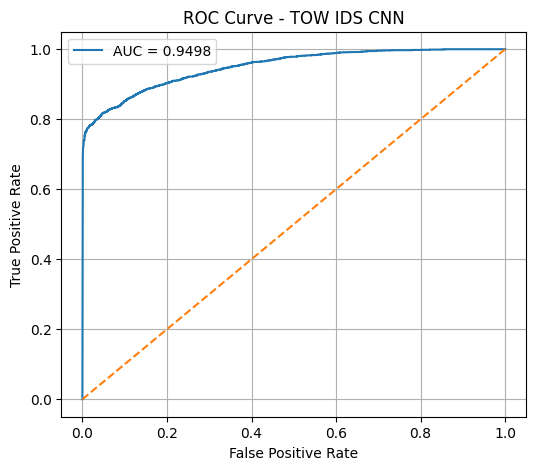

In [19]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TOW IDS CNN")
plt.legend()
plt.grid()
plt.show()


Plot Confusion Matrix

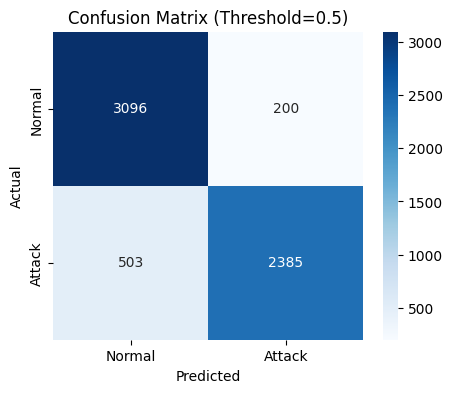

In [20]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted")                                                                                         
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold=0.5)")
plt.show()


Plot Confusion Matrix

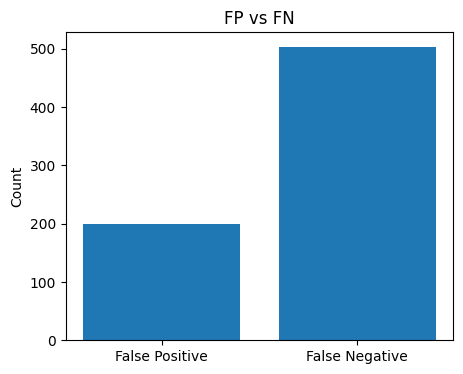

In [21]:
plt.figure(figsize=(5,4))
plt.bar(["False Positive", "False Negative"], [fp, fn])
plt.title("FP vs FN")
plt.ylabel("Count")
plt.show()


Plot FP vs FN

In [22]:
import numpy as np

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden):", best_threshold)


Best Threshold (Youden): 0.73379344


In [23]:
youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.73379344


In [24]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

In [26]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
fmeasure  = 2 * precision * recall / (precision + recall)

print("\n=== Metrics BEST THRESHOLD ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"Precision: {precision:.6f}")
print(f"F-measure: {fmeasure:.6f}")


=== Metrics BEST THRESHOLD ===
Accuracy : 0.889230
Recall   : 0.816828
Precision: 0.937972
F-measure: 0.873219


Threshold Optimization (Youden Index)

In [27]:
y_pred_opt = (y_prob >= best_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)

tn2, fp2, fn2, tp2 = cm_opt.ravel()

acc_opt = (tp2 + tn2) / (tp2 + tn2 + fp2 + fn2)

print("\nAccuracy Optimal:", acc_opt)



Accuracy Optimal: 0.8892302716688227


Detection Speed

In [28]:
import time

start = time.time()
_ = model.predict(X_test[:256])
latency = (time.time() - start) / 256

print("Inference time per sample:", latency)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Inference time per sample: 0.0003880513831973076
